# DifferentialNumpy — Benchmark Suite

**Branch:** `v3`  |  **Target:** CPU & CUDA  
**Paradigm:** clone → run cell-by-cell → fix locally → commit & push → restart kernel → re-run

---

### What this notebook covers

| # | Section | What is measured |
|---|---------|-----------------|
| 1 | **Environment setup** | Colab clone, pip install, device detection |
| 2 | **Op microbenchmarks** | Per-op forward timing: element-wise, reductions, activations, conv/pool |
| 3 | **Device tracking** | `device_op_percentage` — % of ops on CPU vs CUDA |
| 4 | **Model benchmarks** | MLP & CNN forward+backward latency, batch-size scaling |
| 5 | **Training benchmark** | Full training loop throughput (samples/s), CPU vs CUDA comparison |
| 6 | **GPU memory** | CUDA memory footprint per model |
| 7 | **Summary** | Combined results table |


In [1]:
from pathlib import Path
import subprocess
import sys
# ── GPU info ─────────────────────────────────────────────────────────────
print("── GPU info ────────────────────────────────────────────────────")
try:
    r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total,driver_version',
                        '--format=csv,noheader'], capture_output=True, text=True, timeout=10)
    for line in r.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"  {e}")

# ── Clone or pull repo (branch v3) ──────────────────────────────────────
REPO_DIR = Path('/content/AutoDiff-Numpy')
if not REPO_DIR.exists():
    print("\n── Cloning Seydifa/AutoDiff-Numpy (branch v3) ──────────────────")
    subprocess.run(
        ['git', 'clone', '--branch', 'v3', '--depth', '1',
         'https://github.com/Seydifa/AutoDiff-Numpy.git', str(REPO_DIR)],
        check=True,
    )
    print("  Cloned OK")
else:
    print(f"\n── Pulling latest changes in {REPO_DIR} ─────────────────────")
    result = subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'],
                            capture_output=True, text=True)
    print(f"  {result.stdout.strip() or result.stderr.strip()}")

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repo dir:", REPO_DIR)
print("Python  :", sys.version.split()[0])


── GPU info ────────────────────────────────────────────────────
  Tesla T4, 15360 MiB, 580.82.07

── Cloning Seydifa/AutoDiff-Numpy (branch v3) ──────────────────
  Cloned OK
Repo dir: /content/AutoDiff-Numpy
Python  : 3.12.13


In [2]:
# ── 1. Imports & device detection ─────────────────────────────────────────────
import time, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

import dnp
import dnp.ops as ops
from dnp.core.backend import backend, is_cuda_available, synchronize, get_device_count
from dnp.utils import device_op_percentage, reset_device_stats

# ── Detect CUDA ───────────────────────────────────────────────────────────────
CUDA_OK = is_cuda_available
DEVICES  = ["cpu"] + (["cuda"] if CUDA_OK else [])

print(f"{'='*55}")
print(f"  NumPy version  : {np.__version__}")
print(f"  CUDA available : {CUDA_OK}")
if CUDA_OK:
    import cupy as cp
    print(f"  CuPy  version  : {cp.__version__}")
    print(f"  GPU count      : {get_device_count()}")
    dev = cp.cuda.Device(0)
    print(f"  GPU 0          : {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
print(f"{'='*55}")


  NumPy version  : 2.0.2
  CUDA available : True
  CuPy  version  : 14.0.1
  GPU count      : 1
  GPU 0          : Tesla T4


---
## Section 1 — Op Microbenchmarks

Measure per-operation **forward-pass latency (ms)** with and without autograd overhead.

- **`fwd_only`** — raw backend call (NumPy/CuPy), no graph recording  
- **`fwd_graph`** — call through `Ops.__call__` (Tensor node creation + DAG wiring)  
- **`overhead`** — `fwd_graph − fwd_only` (pure autograd bookkeeping cost)  
- **`bwd`** — full forward + `backward()` to scalar loss


In [3]:
# ── Timing helpers ─────────────────────────────────────────────────────────────
REPS_FWD = 200   # repetitions for forward-only timing
REPS_BWD = 50    # repetitions for backward timing

def _sync():
    """GPU synchronize before stopping the clock (no-op on CPU)."""
    synchronize()

def time_raw(fn, *args, reps=REPS_FWD):
    """Time a raw backend call (no autograd). Returns mean ms."""
    _sync()
    t0 = time.perf_counter()
    for _ in range(reps):
        fn(*args)
        _sync()
    return (time.perf_counter() - t0) * 1000 / reps

def time_fwd(op, *tensors, reps=REPS_FWD):
    """Time an Ops forward call (autograd overhead included). Returns mean ms."""
    _sync()
    t0 = time.perf_counter()
    for _ in range(reps):
        op(*tensors)
        _sync()
    return (time.perf_counter() - t0) * 1000 / reps

def time_bwd(op, *tensors, reps=REPS_BWD):
    """Time forward + backward pass. Returns mean ms."""
    from dnp.core.session import session
    _sync()
    t0 = time.perf_counter()
    for _ in range(reps):
        session.reset()
        out = op(*tensors)
        # reduce to scalar if needed
        if hasattr(out, "data") and out.data.ndim > 0:
            loss = ops.mean(ops.sum(out))
        else:
            loss = out
        if hasattr(loss, "backward"):
            loss.backward()
        _sync()
    return (time.perf_counter() - t0) * 1000 / reps

def make_tensor(shape, device="cpu"):
    """Create a random Tensor on the specified device."""
    dnp.set_device(device)
    return dnp.Tensor(np.random.randn(*shape).astype(np.float32))

def benchmark_op(name, raw_fn, op, shapes, device="cpu", reps_fwd=REPS_FWD, reps_bwd=REPS_BWD):
    """Run full benchmark for one op on one device. Returns a dict row."""
    dnp.set_device(device)
    tensors = [make_tensor(s, device) for s in shapes]
    raw_args = [t.data for t in tensors]

    fwd_only  = time_raw(raw_fn, *raw_args, reps=reps_fwd)
    fwd_graph = time_fwd(op, *tensors, reps=reps_fwd)
    bwd_time  = time_bwd(op, *tensors, reps=reps_bwd)
    overhead  = fwd_graph - fwd_only

    return dict(op=name, device=device,
                fwd_only_ms=round(fwd_only, 4),
                fwd_graph_ms=round(fwd_graph, 4),
                overhead_ms=round(overhead, 4),
                bwd_ms=round(bwd_time, 4))

print("Timing helpers ready.")


Timing helpers ready.


In [4]:
# ── Element-wise & activation op benchmarks ──────────────────────────────────
# Shape used: (512, 512) for element-wise, (1024, 1024) for activations

S2D   = (512, 512)
S2D_L = (1024, 1024)

OP_SPECS = [
    # (display_name, raw_backend_fn, ops_instance, [shapes])
    ("add",       lambda a, b: backend.add(a, b),         ops.add,       [S2D, S2D]),
    ("multiply",  lambda a, b: backend.multiply(a, b),    ops.multiply,  [S2D, S2D]),
    ("matmul",    lambda a, b: backend.matmul(a, b),      ops.matmul,    [S2D, S2D]),
    ("exp",       lambda a: backend.exp(a),               ops.exp,       [S2D]),
    ("log",       lambda a: backend.log(backend.abs(a) + 1e-6), ops.log, [S2D]),
    ("sqrt",      lambda a: backend.sqrt(backend.abs(a)), ops.sqrt,      [S2D]),
    ("sum",       lambda a: backend.sum(a),               ops.sum,       [S2D]),
    ("mean",      lambda a: backend.mean(a),              ops.mean,      [S2D]),
    ("relu",      lambda a: backend.maximum(a, 0),        ops.relu,      [S2D_L]),
    ("sigmoid",   lambda a: 1/(1+backend.exp(-a)),        ops.sigmoid,   [S2D_L]),
    ("tanh",      lambda a: backend.tanh(a),              ops.tanh,      [S2D_L]),
    ("softmax",   lambda a: backend.exp(a)/backend.sum(backend.exp(a),axis=-1,keepdims=True),
                            ops.softmax, [S2D_L]),
]

op_rows = []
for device in DEVICES:
    print(f"\n[{device.upper()}] benchmarking {len(OP_SPECS)} ops …")
    for name, raw_fn, op, shapes in OP_SPECS:
        row = benchmark_op(name, raw_fn, op, shapes, device=device)
        op_rows.append(row)
        print(f"  {name:12s}  fwd_only={row['fwd_only_ms']:.4f}ms  "
              f"fwd_graph={row['fwd_graph_ms']:.4f}ms  "
              f"overhead={row['overhead_ms']:.4f}ms  "
              f"bwd={row['bwd_ms']:.4f}ms")

df_ops = pd.DataFrame(op_rows)
print("\nDone.")



[CPU] benchmarking 12 ops …
  add           fwd_only=0.2874ms  fwd_graph=0.3126ms  overhead=0.0252ms  bwd=1.3680ms
  multiply      fwd_only=0.2784ms  fwd_graph=0.3418ms  overhead=0.0634ms  bwd=2.1757ms
  matmul        fwd_only=4.7763ms  fwd_graph=4.7583ms  overhead=-0.0180ms  bwd=19.6126ms
  exp           fwd_only=0.5478ms  fwd_graph=0.6740ms  overhead=0.1263ms  bwd=2.6062ms
  log           fwd_only=1.0629ms  fwd_graph=2.9896ms  overhead=1.9266ms  bwd=5.5735ms
  sqrt          fwd_only=0.5059ms  fwd_graph=0.3392ms  overhead=-0.1667ms  bwd=3.2586ms
  sum           fwd_only=0.1608ms  fwd_graph=0.2225ms  overhead=0.0617ms  bwd=0.4930ms
  mean          fwd_only=0.1604ms  fwd_graph=0.2585ms  overhead=0.0981ms  bwd=1.8495ms
  relu          fwd_only=1.9777ms  fwd_graph=1.6126ms  overhead=-0.3651ms  bwd=9.0875ms
  sigmoid       fwd_only=7.0970ms  fwd_graph=13.6728ms  overhead=6.5758ms  bwd=28.0533ms
  tanh          fwd_only=3.9390ms  fwd_graph=3.9813ms  overhead=0.0423ms  bwd=17.5393ms
  softm

In [5]:

# ── Conv2d & Pooling benchmarks ───────────────────────────────────────────────
import functools
from dnp.core.ops import conv2d_nd, max_pool2d, avg_pool2d

# Input: (batch=16, C=32, H=32, W=32)  kernel 3×3
# conv2d_nd(x, W, stride_h=1, stride_w=1, pad_h=0, pad_w=0)
# max_pool2d / avg_pool2d require kernel_size — bake in kernel_size=2
CONV_SHAPE  = (16, 32, 32, 32)
KERN_SHAPE  = (64, 32, 3, 3)

_max_pool_k2 = functools.partial(max_pool2d, kernel_size=2)
_avg_pool_k2 = functools.partial(avg_pool2d, kernel_size=2)

conv_rows = []
for device in DEVICES:
    print(f"\n[{device.upper()}] conv2d / pooling …")
    dnp.set_device(device)

    x_t = make_tensor(CONV_SHAPE, device)
    k_t = make_tensor(KERN_SHAPE, device)

    # conv2d_nd  (4-D batched convolution)
    fwd_c = time_fwd(conv2d_nd, x_t, k_t, reps=30)
    bwd_c = time_bwd(conv2d_nd, x_t, k_t, reps=10)
    print(f"  conv2d_nd     fwd={fwd_c:.4f}ms  bwd={bwd_c:.4f}ms")
    conv_rows.append(dict(op="conv2d_nd", device=device,
                          fwd_graph_ms=round(fwd_c,4), bwd_ms=round(bwd_c,4),
                          fwd_only_ms=float("nan"), overhead_ms=float("nan")))

    # max_pool2d  (kernel_size=2)
    x_p = make_tensor(CONV_SHAPE, device)
    fwd_p = time_fwd(_max_pool_k2, x_p, reps=50)
    bwd_p = time_bwd(_max_pool_k2, x_p, reps=20)
    print(f"  max_pool2d    fwd={fwd_p:.4f}ms  bwd={bwd_p:.4f}ms")
    conv_rows.append(dict(op="max_pool2d", device=device,
                          fwd_graph_ms=round(fwd_p,4), bwd_ms=round(bwd_p,4),
                          fwd_only_ms=float("nan"), overhead_ms=float("nan")))

    # avg_pool2d  (kernel_size=2)
    fwd_a = time_fwd(_avg_pool_k2, x_p, reps=50)
    bwd_a = time_bwd(_avg_pool_k2, x_p, reps=20)
    print(f"  avg_pool2d    fwd={fwd_a:.4f}ms  bwd={bwd_a:.4f}ms")
    conv_rows.append(dict(op="avg_pool2d", device=device,
                          fwd_graph_ms=round(fwd_a,4), bwd_ms=round(bwd_a,4),
                          fwd_only_ms=float("nan"), overhead_ms=float("nan")))

df_conv = pd.DataFrame(conv_rows)
print("\nDone.")



[CPU] conv2d / pooling …
  conv2d_nd     fwd=20.1297ms  bwd=334.5217ms
  max_pool2d    fwd=45.9261ms  bwd=82.2689ms
  avg_pool2d    fwd=20.6035ms  bwd=64.7364ms

[CUDA] conv2d / pooling …
  conv2d_nd     fwd=14.2657ms  bwd=142.7505ms
  max_pool2d    fwd=3.0997ms  bwd=35.7017ms
  avg_pool2d    fwd=3.0986ms  bwd=18.3934ms

Done.


Op Microbenchmark Results (ms)
        op device  fwd_only_ms  fwd_graph_ms  overhead_ms   bwd_ms
       add    cpu       0.2874        0.3126       0.0252   1.3680
  multiply    cpu       0.2784        0.3418       0.0634   2.1757
    matmul    cpu       4.7763        4.7583      -0.0180  19.6126
       exp    cpu       0.5478        0.6740       0.1263   2.6062
       log    cpu       1.0629        2.9896       1.9266   5.5735
      sqrt    cpu       0.5059        0.3392      -0.1667   3.2586
       sum    cpu       0.1608        0.2225       0.0617   0.4930
      mean    cpu       0.1604        0.2585       0.0981   1.8495
      relu    cpu       1.9777        1.6126      -0.3651   9.0875
   sigmoid    cpu       7.0970       13.6728       6.5758  28.0533
      tanh    cpu       3.9390        3.9813       0.0423  17.5393
   softmax    cpu      12.2115       10.1858      -2.0257  24.0789
       add   cuda       0.5433        0.0529      -0.4904  12.6725
  multiply   cuda       0.5611 

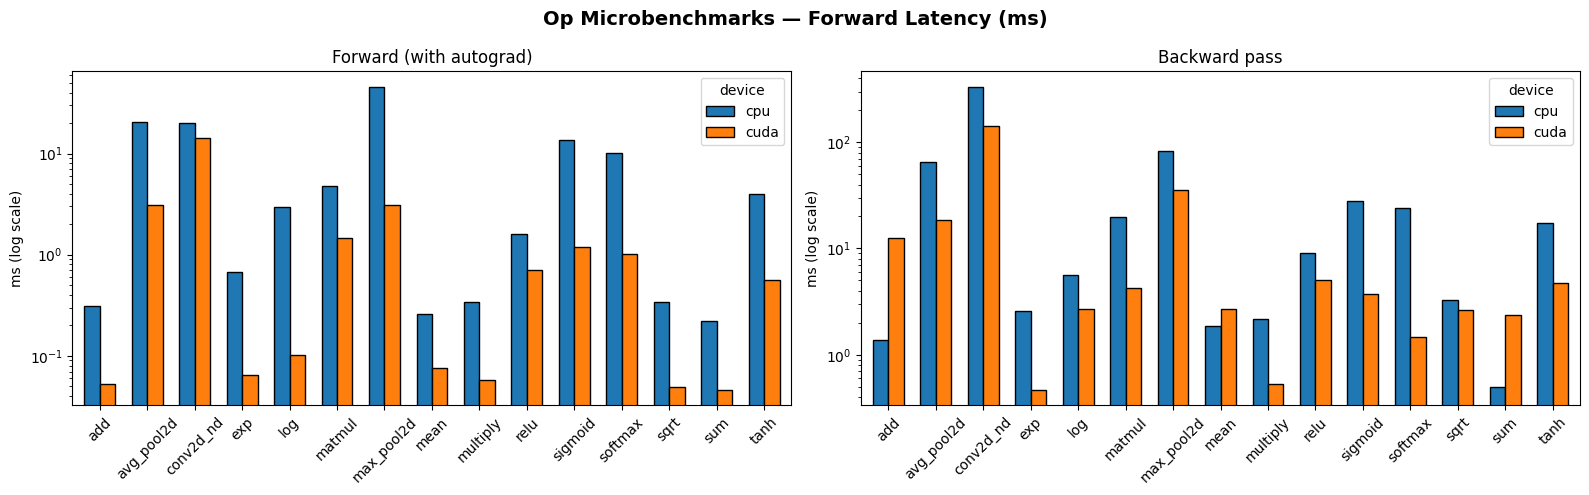

In [6]:
# ── Section 1 Results Table & Plot ────────────────────────────────────────────
df_all_ops = pd.concat([df_ops, df_conv], ignore_index=True)

print("=" * 80)
print("Op Microbenchmark Results (ms)")
print("=" * 80)
print(df_all_ops.to_string(index=False))
print("=" * 80)

# --- Chart: forward latency comparison (CPU vs CUDA) -------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Op Microbenchmarks — Forward Latency (ms)", fontsize=14, fontweight="bold")

for ax, metric, title in zip(
    axes,
    ["fwd_graph_ms", "bwd_ms"],
    ["Forward (with autograd)", "Backward pass"],
):
    pivot = df_all_ops.pivot_table(index="op", columns="device", values=metric)
    pivot.plot(kind="bar", ax=ax, width=0.65, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("ms (log scale)")
    ax.set_yscale("log")
    ax.legend(title="device")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


---
## Section 2 — Device Tracking with `device_op_percentage`

`dnp.utils.device_op_percentage(device)` counts what fraction of all `Ops.__call__` invocations ran on a given device since the last `reset_device_stats()`.  
Useful for validating that a model is fully on GPU or diagnosing unintended CPU fallbacks.


In [8]:

# ── Device tracking demo ──────────────────────────────────────────────────────
# P5: device_stats is opt-in (enabled=False by default). Enable it here.
from dnp.core.session import session
from dnp.core.ops import device_stats
device_stats.enabled = True

def _run_mlp_forward(device, n_steps=20):
    """Run n_steps forward passes of a small MLP and return device %-stats."""
    reset_device_stats()
    dnp.set_device(device)

    W1 = make_tensor((128, 256), device)
    b1 = make_tensor((256,),     device)
    W2 = make_tensor((256, 128), device)
    b2 = make_tensor((128,),     device)
    W3 = make_tensor((128, 10),  device)
    b3 = make_tensor((10,),      device)

    for _ in range(n_steps):
        session.reset()
        x  = make_tensor((32, 128), device)
        h1 = ops.relu(ops.add(ops.matmul(x, W1), b1))
        h2 = ops.relu(ops.add(ops.matmul(h1, W2), b2))
        _  = ops.add(ops.matmul(h2, W3), b3)

    return {
        "device_requested": device,
        "cpu_%":  round(device_op_percentage("cpu"),  2),
        "cuda_%": round(device_op_percentage("cuda"), 2),
    }

tracking_rows = []
for dev in DEVICES:
    row = _run_mlp_forward(dev)
    tracking_rows.append(row)
    print(f"Requested={dev:4s}  →  CPU: {row['cpu_%']:6.2f}%   CUDA: {row['cuda_%']:6.2f}%")

# If CUDA available, show a mixed scenario (ops starting on CPU then switching)
if CUDA_OK:
    reset_device_stats()
    dnp.set_device("cpu")
    a = ops.add(make_tensor((256, 256), "cpu"), make_tensor((256, 256), "cpu"))
    dnp.set_device("cuda")
    b = ops.matmul(make_tensor((256, 256), "cuda"), make_tensor((256, 256), "cuda"))
    print(f"\nMixed scenario → CPU: {device_op_percentage('cpu'):.1f}%  "
          f"CUDA: {device_op_percentage('cuda'):.1f}%")

# Leave enabled for the training benchmark too; disable afterward.
# (disabled after the training section runs — see Section 4 cell)


Requested=cpu   →  CPU: 100.00%   CUDA:   0.00%
Requested=cuda  →  CPU:   0.00%   CUDA: 100.00%

Mixed scenario → CPU: 50.0%  CUDA: 50.0%


---
## Section 3 — Model Benchmarks

Three architectures are tested end-to-end:

| Model | Architecture | Task |
|-------|-------------|------|
| **MLP-S** | `128 → 256 → 128 → 10` | toy classification |
| **MLP-L** | `784 → 512 → 256 → 128 → 10` | larger MLP |
| **CNN** | `Conv2d(3→32,3×3) → ReLU → MaxPool → Conv2d(32→64,3×3) → ReLU → GAP → Linear(64,10)` | image-like input |

Metrics reported: **forward ms**, **backward ms**, and **params count**.


In [9]:

# ── Model definitions ─────────────────────────────────────────────────────────

class MLP_S(dnp.Module):
    """Small MLP: 128 → 256 → 128 → 10."""
    def __init__(self):
        super().__init__()
        self.fc1 = dnp.Linear(128, 256, name="fc1")
        self.fc2 = dnp.Linear(256, 128, name="fc2")
        self.fc3 = dnp.Linear(128,  10, name="fc3")
    def forward(self, x):
        return self.fc3(ops.relu(self.fc2(ops.relu(self.fc1(x)))))


class MLP_L(dnp.Module):
    """Large MLP: 784 → 512 → 256 → 128 → 10."""
    def __init__(self):
        super().__init__()
        self.fc1 = dnp.Linear(784, 512, name="fc1")
        self.fc2 = dnp.Linear(512, 256, name="fc2")
        self.fc3 = dnp.Linear(256, 128, name="fc3")
        self.fc4 = dnp.Linear(128,  10, name="fc4")
    def forward(self, x):
        x = ops.relu(self.fc1(x))
        x = ops.relu(self.fc2(x))
        x = ops.relu(self.fc3(x))
        return self.fc4(x)


class CNN(dnp.Module):
    """Tiny CNN: 2 conv layers + global avg pool + linear head."""
    def __init__(self):
        super().__init__()
        self.conv1 = dnp.Conv2d(3,  32, kernel_size=3, padding=1)
        self.conv2 = dnp.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = dnp.MaxPool2d(kernel_size=2)
        self.gap   = dnp.GlobalAvgPool2d()
        self.fc    = dnp.Linear(64, 10, name="fc")
    def forward(self, x):
        x = ops.relu(self.conv1(x))
        x = self.pool(x)
        x = ops.relu(self.conv2(x))
        x = self.gap(x)
        return self.fc(x)


def count_params(model):
    return sum(p.data.size for p in model.parameters())

print("MLP-S  params:", count_params(MLP_S()))
print("MLP-L  params:", count_params(MLP_L()))
print("CNN    params:", count_params(CNN()))


MLP-S  params: 67210
MLP-L  params: 567434
CNN    params: 20042


In [10]:

# ── Model forward + backward benchmark ───────────────────────────────────────
BATCH = 64       # samples per step
REPS  = 30       # repetitions

def _move_params(model, device):
    """Move all model parameters to the target device."""
    from dnp.core.backend import as_cupy, as_numpy
    for p in model.parameters():
        if device == "cuda":
            p.data = as_cupy(p.data)
        else:
            p.data = as_numpy(p.data)
        p.grad = None  # reset gradient (may be None for fresh models)

def benchmark_model(name, model_cls, batch_shape, device, reps=REPS):
    """Benchmark one model on one device. Returns a result dict."""
    dnp.set_device(device)
    model = model_cls()
    _move_params(model, device)
    loss_fn = dnp.CrossEntropyLoss()

    # Warmup
    for _ in range(3):
        session.reset()
        x = make_tensor(batch_shape, device)
        y_idx = np.random.randint(0, 10, size=(batch_shape[0],))
        from dnp.core.backend import as_cupy
        if device == "cuda":
            y_idx = as_cupy(y_idx)
        y = dnp.Tensor(y_idx)
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
    _sync()

    # Forward timing
    t_fwd = []
    for _ in range(reps):
        session.reset()
        x = make_tensor(batch_shape, device)
        _sync(); t0 = time.perf_counter()
        out = model(x)
        _sync()
        t_fwd.append((time.perf_counter() - t0) * 1000)

    # Forward+backward timing
    t_bwd = []
    for _ in range(reps):
        session.reset()
        x = make_tensor(batch_shape, device)
        y_idx = np.random.randint(0, 10, size=(batch_shape[0],))
        if device == "cuda":
            y_idx = as_cupy(y_idx)
        y = dnp.Tensor(y_idx)
        _sync(); t0 = time.perf_counter()
        out  = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        _sync()
        t_bwd.append((time.perf_counter() - t0) * 1000)

    return dict(
        model=name,
        device=device,
        params=count_params(model),
        fwd_ms      = round(float(np.mean(t_fwd)),  3),
        fwd_std_ms  = round(float(np.std(t_fwd)),   3),
        bwd_ms      = round(float(np.mean(t_bwd)),  3),
        bwd_std_ms  = round(float(np.std(t_bwd)),   3),
        throughput  = round(batch_shape[0] / (float(np.mean(t_bwd)) / 1000), 1),
    )


MODEL_SPECS = [
    ("MLP-S",  MLP_S, (BATCH, 128)),
    ("MLP-L",  MLP_L, (BATCH, 784)),
    ("CNN",    CNN,   (BATCH,  3, 32, 32)),
]

model_rows = []
for device in DEVICES:
    print(f"\n[{device.upper()}]")
    for mname, mcls, batch_shape in MODEL_SPECS:
        row = benchmark_model(mname, mcls, batch_shape, device)
        model_rows.append(row)
        print(f"  {mname:6s}  fwd={row['fwd_ms']:.3f}ms(±{row['fwd_std_ms']:.3f})  "
              f"bwd={row['bwd_ms']:.3f}ms(±{row['bwd_std_ms']:.3f})  "
              f"throughput={row['throughput']:.0f} samples/s")

df_models = pd.DataFrame(model_rows)



[CPU]
  MLP-S   fwd=0.724ms(±0.084)  bwd=2.090ms(±0.160)  throughput=30626 samples/s
  MLP-L   fwd=3.218ms(±1.499)  bwd=10.347ms(±3.548)  throughput=6185 samples/s
  CNN     fwd=147.789ms(±12.546)  bwd=486.876ms(±175.627)  throughput=132 samples/s

[CUDA]
  MLP-S   fwd=0.845ms(±0.006)  bwd=3.245ms(±0.087)  throughput=19724 samples/s
  MLP-L   fwd=1.375ms(±0.029)  bwd=4.262ms(±0.263)  throughput=15016 samples/s
  CNN     fwd=6.730ms(±0.882)  bwd=21.082ms(±0.219)  throughput=3036 samples/s



[CPU] MLP-L batch-size scaling …
  bs=   8  fwd=1.278ms  throughput=6259 samples/s
  bs=  16  fwd=1.267ms  throughput=12629 samples/s
  bs=  32  fwd=2.205ms  throughput=14512 samples/s
  bs=  64  fwd=2.650ms  throughput=24153 samples/s
  bs= 128  fwd=4.004ms  throughput=31968 samples/s
  bs= 256  fwd=6.689ms  throughput=38274 samples/s

[CUDA] MLP-L batch-size scaling …
  bs=   8  fwd=1.432ms  throughput=5587 samples/s
  bs=  16  fwd=1.443ms  throughput=11090 samples/s
  bs=  32  fwd=1.664ms  throughput=19232 samples/s
  bs=  64  fwd=1.686ms  throughput=37951 samples/s
  bs= 128  fwd=1.869ms  throughput=68501 samples/s
  bs= 256  fwd=3.058ms  throughput=83724 samples/s


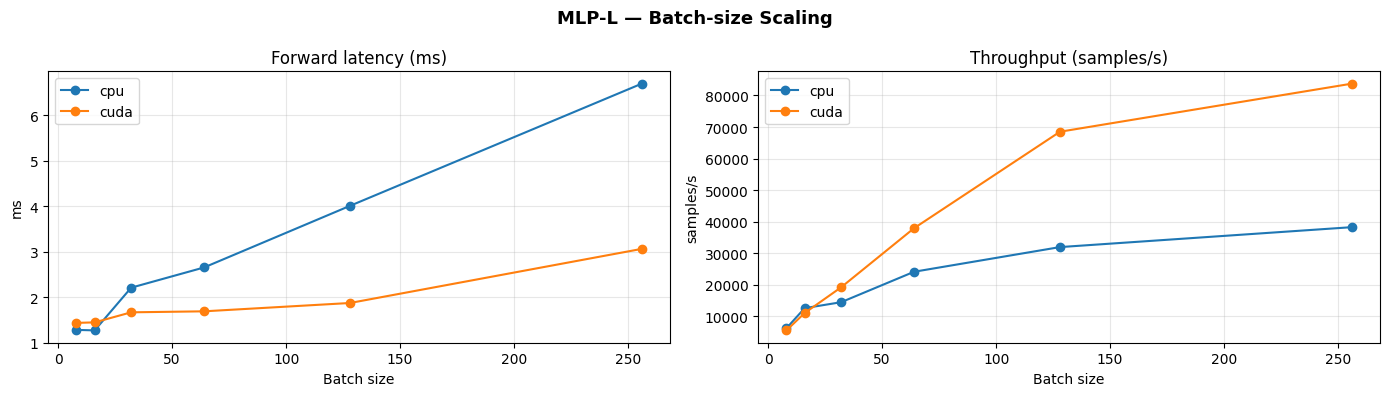

In [11]:
# ── Batch-size scaling ────────────────────────────────────────────────────────
# How does MLP-L throughput scale with batch size on each device?

BATCH_SIZES = [8, 16, 32, 64, 128, 256]
SCALE_REPS  = 20

scale_rows = []
for device in DEVICES:
    print(f"\n[{device.upper()}] MLP-L batch-size scaling …")
    dnp.set_device(device)
    for bs in BATCH_SIZES:
        model = MLP_L()
        _move_params(model, device)
        # warmup
        for _ in range(3):
            session.reset()
            x = make_tensor((bs, 784), device)
            model(x)
        _sync()
        # measure
        times = []
        for _ in range(SCALE_REPS):
            session.reset()
            x = make_tensor((bs, 784), device)
            _sync(); t0 = time.perf_counter()
            model(x)
            _sync()
            times.append((time.perf_counter() - t0) * 1000)
        tp = round(bs / (float(np.mean(times)) / 1000), 1)
        scale_rows.append(dict(device=device, batch=bs,
                               fwd_ms=round(float(np.mean(times)), 3),
                               throughput=tp))
        print(f"  bs={bs:4d}  fwd={float(np.mean(times)):.3f}ms  throughput={tp:.0f} samples/s")

df_scale = pd.DataFrame(scale_rows)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("MLP-L — Batch-size Scaling", fontsize=13, fontweight="bold")

for device, grp in df_scale.groupby("device"):
    axes[0].plot(grp["batch"], grp["fwd_ms"],       marker="o", label=device)
    axes[1].plot(grp["batch"], grp["throughput"],   marker="o", label=device)

axes[0].set(title="Forward latency (ms)", xlabel="Batch size", ylabel="ms")
axes[1].set(title="Throughput (samples/s)", xlabel="Batch size", ylabel="samples/s")
for ax in axes:
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Section 4 — Training Throughput Benchmark

Run 50 epochs of a real training loop on synthetic data (10 k samples, 10-class).  
Reports **loss curve**, **epoch time**, and **samples/s**.


In [12]:

# ── Training benchmark ────────────────────────────────────────────────────────
from dnp.utils import Trainer, EarlyStopping, History

N_SAMPLES  = 2000   # synthetic samples (keep small for speed)
N_FEATURES = 128
N_CLASSES  = 10
EPOCHS     = 30
BATCH_SIZE = 64

# Generate synthetic data (CPU numpy)
rng = np.random.default_rng(42)
X_np = rng.standard_normal((N_SAMPLES, N_FEATURES)).astype(np.float32)
y_np = rng.integers(0, N_CLASSES, size=N_SAMPLES)

train_results = {}

for device in DEVICES:
    print(f"\n[{device.upper()}] training MLP-S  {N_SAMPLES} samples × {EPOCHS} epochs …")
    reset_device_stats()           # device_stats.enabled=True set in Section 2
    dnp.set_device(device)

    model     = MLP_S()
    _move_params(model, device)
    optimizer = dnp.Adam(model.parameters(), lr=3e-3)
    loss_fn   = dnp.CrossEntropyLoss()

    history   = History()
    epoch_times = []

    for epoch in range(EPOCHS):
        t0 = time.perf_counter()
        session.reset()

        # Mini-batch SGD
        idx = rng.permutation(N_SAMPLES)
        losses_epoch = []
        for start in range(0, N_SAMPLES, BATCH_SIZE):
            batch_idx = idx[start:start + BATCH_SIZE]
            xb = X_np[batch_idx]
            yb = y_np[batch_idx]

            dnp.set_device(device)
            xb_t  = dnp.Tensor(xb)
            yb_t  = dnp.Tensor(yb)

            session.reset()
            optimizer.zero_grad()
            out  = model(xb_t)
            loss = loss_fn(out, yb_t)
            loss.backward()
            optimizer.step()
            losses_epoch.append(float(loss.data))

        epoch_ms     = (time.perf_counter() - t0) * 1000
        mean_loss    = float(np.mean(losses_epoch))
        throughput   = N_SAMPLES / (epoch_ms / 1000)
        epoch_times.append(epoch_ms)

        if (epoch + 1) % 5 == 0:
            print(f"  epoch {epoch+1:3d}/{EPOCHS}  loss={mean_loss:.4f}  "
                  f"epoch_time={epoch_ms:.1f}ms  throughput={throughput:.0f} samp/s")
        history.history.setdefault("loss", []).append(mean_loss)

    train_results[device] = dict(
        history     = history,
        epoch_times = epoch_times,
        cpu_pct     = device_op_percentage("cpu"),
        cuda_pct    = device_op_percentage("cuda"),
    )
    print(f"  → Avg epoch: {np.mean(epoch_times):.1f}ms  "
          f"CPU%={device_op_percentage('cpu'):.1f}  CUDA%={device_op_percentage('cuda'):.1f}")

# Done tracking — disable device_stats to avoid overhead in subsequent cells
device_stats.enabled = False



[CPU] training MLP-S  2000 samples × 30 epochs …
  epoch   5/30  loss=0.7992  epoch_time=830.5ms  throughput=2408 samp/s
  epoch  10/30  loss=0.0174  epoch_time=174.4ms  throughput=11466 samp/s
  epoch  15/30  loss=0.0057  epoch_time=99.3ms  throughput=20131 samp/s
  epoch  20/30  loss=0.0030  epoch_time=98.5ms  throughput=20309 samp/s
  epoch  25/30  loss=0.0019  epoch_time=96.2ms  throughput=20786 samp/s
  epoch  30/30  loss=0.0013  epoch_time=97.4ms  throughput=20524 samp/s
  → Avg epoch: 173.8ms  CPU%=100.0  CUDA%=0.0

[CUDA] training MLP-S  2000 samples × 30 epochs …
  epoch   5/30  loss=0.7145  epoch_time=158.0ms  throughput=12655 samp/s
  epoch  10/30  loss=0.0169  epoch_time=149.4ms  throughput=13383 samp/s
  epoch  15/30  loss=0.0059  epoch_time=151.0ms  throughput=13242 samp/s
  epoch  20/30  loss=0.0032  epoch_time=149.2ms  throughput=13404 samp/s
  epoch  25/30  loss=0.0020  epoch_time=163.8ms  throughput=12210 samp/s
  epoch  30/30  loss=0.0013  epoch_time=151.7ms  throug

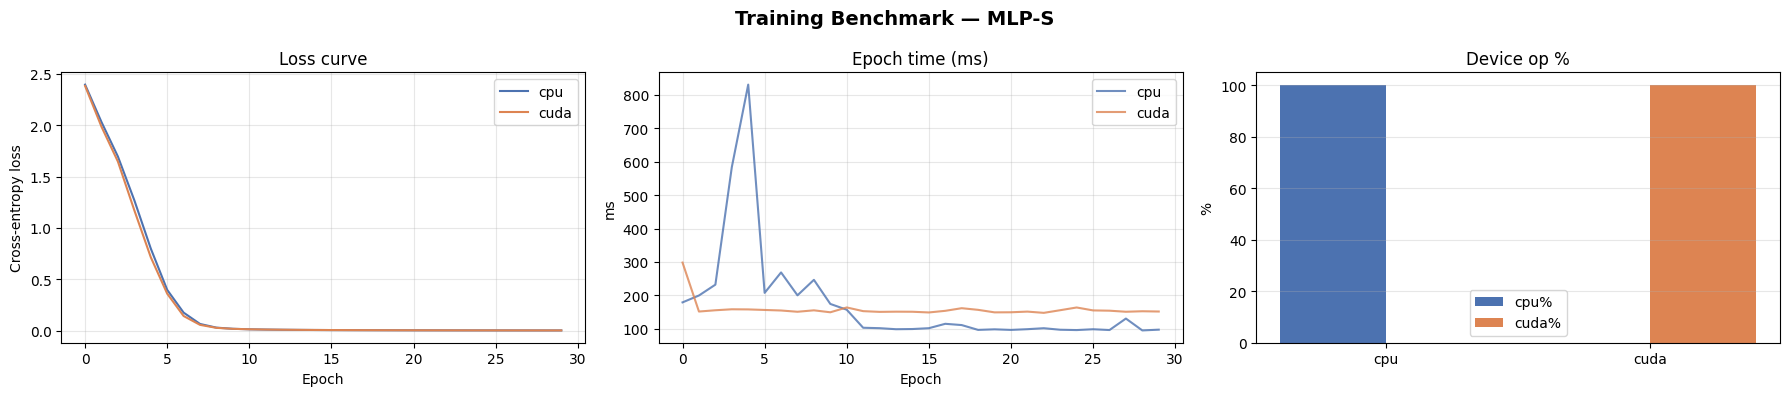

In [13]:
# ── Training results plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Training Benchmark — MLP-S", fontsize=14, fontweight="bold")

colors = {"cpu": "#4C72B0", "cuda": "#DD8452"}

# Loss curves
ax = axes[0]
for dev, res in train_results.items():
    ax.plot(res["history"].history["loss"], label=dev, color=colors.get(dev))
ax.set(title="Loss curve", xlabel="Epoch", ylabel="Cross-entropy loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Epoch time over training
ax = axes[1]
for dev, res in train_results.items():
    ax.plot(res["epoch_times"], label=dev, color=colors.get(dev), alpha=0.8)
ax.set(title="Epoch time (ms)", xlabel="Epoch", ylabel="ms")
ax.legend(); ax.grid(True, alpha=0.3)

# Device op % pie charts
ax = axes[2]
if len(train_results) == 1:
    dev  = list(train_results.keys())[0]
    res  = train_results[dev]
    vals = [res["cpu_pct"], res["cuda_pct"]]
    lbls = ["cpu", "cuda"]
    ax.pie(vals, labels=lbls, autopct="%1.1f%%",
           colors=[colors["cpu"], colors["cuda"]])
    ax.set_title(f"Device usage ({dev})")
else:
    # Grouped bars when both CPU and CUDA are available
    devs  = list(train_results.keys())
    cpus  = [train_results[d]["cpu_pct"]  for d in devs]
    cudas = [train_results[d]["cuda_pct"] for d in devs]
    x = np.arange(len(devs))
    ax.bar(x - 0.2, cpus,  0.4, label="cpu%",  color=colors["cpu"])
    ax.bar(x + 0.2, cudas, 0.4, label="cuda%", color=colors["cuda"])
    ax.set_xticks(x); ax.set_xticklabels(devs)
    ax.set(title="Device op %", ylabel="%")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()



---
## Section 4b — `Trainer` API Benchmark (CPU vs GPU)

Uses the high-level `dnp.utils.Trainer` class (callbacks, mini-batch loop, history).  
Data is fed as **NumPy arrays (CPU)** or **CuPy arrays (GPU)** — the Trainer wraps each  
batch in a `Tensor` automatically, so no manual data-movement code is needed.

Metrics: final loss, avg epoch time, throughput (samples/s).



[CPU] Trainer.fit  MLP-S  2000 samples × 30 epochs …
  total=3.50s  avg_epoch=116.6ms  throughput=17150 samp/s  final_loss=2.345537

[CUDA] Trainer.fit  MLP-S  2000 samples × 30 epochs …
  total=4.51s  avg_epoch=150.2ms  throughput=13316 samp/s  final_loss=2.337758


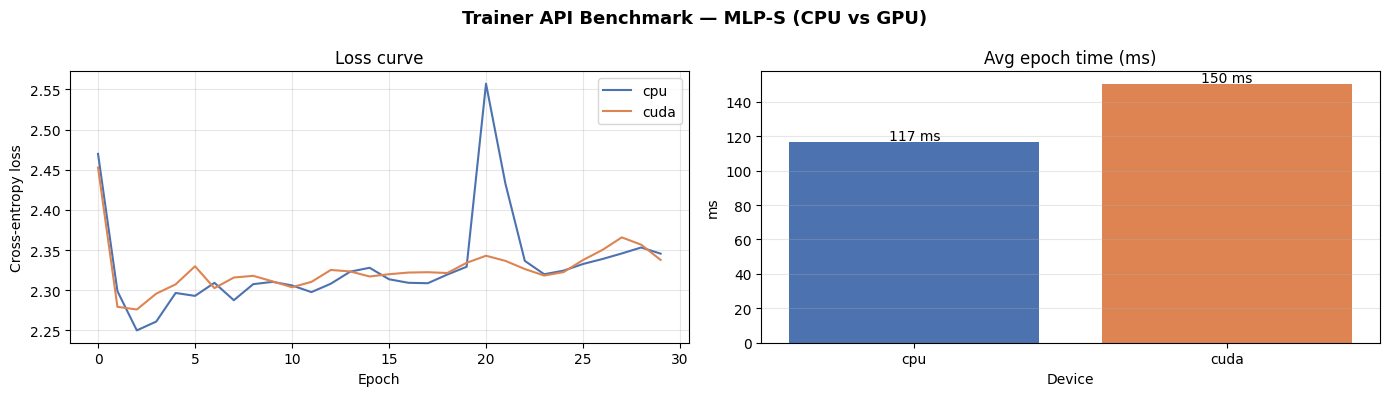


──────────────────────────────────────────────────────────────
  device    avg_epoch_ms      throughput    final_loss
──────────────────────────────────────────────────────────────
  cpu              116.6           17150      2.345537
  cuda             150.2           13316      2.337758
──────────────────────────────────────────────────────────────
  GPU speedup: 0.78x faster than CPU



In [ ]:

# ── Trainer API benchmark (CPU vs GPU) ───────────────────────────────────────
# Pull latest changes (picks up zero_grad fix in Trainer.fit) then reload
import subprocess, importlib
subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True, capture_output=True)
import dnp.utils.trainer as _trmod
importlib.reload(_trmod)
from dnp.utils.trainer import Trainer, History

TRAINER_EPOCHS     = 30
TRAINER_BATCH_SIZE = 64

# Prepare numpy data (same seed as the manual training loop)
_rng = np.random.default_rng(42)
X_tr = _rng.standard_normal((N_SAMPLES, N_FEATURES)).astype(np.float32)
y_tr = _rng.integers(0, N_CLASSES, size=N_SAMPLES).astype(np.int64)

trainer_results = {}

for device in DEVICES:
    print(f"\n[{device.upper()}] Trainer.fit  MLP-S  {N_SAMPLES} samples × {TRAINER_EPOCHS} epochs …")
    dnp.set_device(device)

    # Move input data to the right device
    if device == "cuda" and CUDA_OK:
        import cupy as cp
        X_dev = cp.asarray(X_tr)
        y_dev = cp.asarray(y_tr)
    else:
        X_dev = X_tr
        y_dev = y_tr

    # Build fresh model and move params to device
    _model_tr = MLP_S()
    _move_params(_model_tr, device)
    _opt_tr   = dnp.Adam(_model_tr.parameters(), lr=3e-3)
    _loss_tr  = dnp.CrossEntropyLoss()

    trainer = Trainer(
        _model_tr, _opt_tr, _loss_tr,
        verbose=False,   # silence per-epoch logs; we report summary below
    )

    t_start = time.perf_counter()
    hist = trainer.fit(X_dev, y_dev,
                       epochs=TRAINER_EPOCHS,
                       batch_size=TRAINER_BATCH_SIZE)
    total_s = time.perf_counter() - t_start

    final_loss  = hist.history["loss"][-1]
    avg_ep_ms   = total_s / TRAINER_EPOCHS * 1000
    throughput  = N_SAMPLES / (total_s / TRAINER_EPOCHS)

    trainer_results[device] = dict(
        history    = hist,
        total_s    = round(total_s, 3),
        avg_ep_ms  = round(avg_ep_ms, 1),
        throughput = round(throughput, 0),
        final_loss = round(final_loss, 6),
    )
    print(f"  total={total_s:.2f}s  avg_epoch={avg_ep_ms:.1f}ms  "
          f"throughput={throughput:.0f} samp/s  final_loss={final_loss:.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Trainer API Benchmark — MLP-S (CPU vs GPU)", fontsize=13, fontweight="bold")

_colors = {"cpu": "#4C72B0", "cuda": "#DD8452"}
for dev, res in trainer_results.items():
    axes[0].plot(res["history"].history["loss"], label=dev, color=_colors.get(dev))
axes[0].set(title="Loss curve", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

devs_list   = list(trainer_results.keys())
avg_ep_vals = [trainer_results[d]["avg_ep_ms"]  for d in devs_list]
axes[1].bar(devs_list, avg_ep_vals,
            color=[_colors.get(d, "gray") for d in devs_list])
axes[1].set(title="Avg epoch time (ms)", xlabel="Device", ylabel="ms")
for i, v in enumerate(avg_ep_vals):
    axes[1].text(i, v * 1.01, f"{v:.0f} ms", ha="center", fontsize=10)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "─"*62)
print(f"  {'device':6s}  {'avg_epoch_ms':>14s}  {'throughput':>14s}  {'final_loss':>12s}")
print("─"*62)
for dev, res in trainer_results.items():
    print(f"  {dev:6s}  {res['avg_ep_ms']:>14.1f}  "
          f"{res['throughput']:>14.0f}  {res['final_loss']:>12.6f}")
print("─"*62)
if len(trainer_results) == 2 and "cpu" in trainer_results and "cuda" in trainer_results:
    speedup = trainer_results["cpu"]["avg_ep_ms"] / trainer_results["cuda"]["avg_ep_ms"]
    print(f"  GPU speedup: {speedup:.2f}x faster than CPU")
print()


---
## Section 5 — GPU Memory Footprint  *(CUDA only)*

Measures peak CuPy memory allocated during model forward+backward — useful to estimate how large a batch can fit in VRAM.


  MLP-S   bs= 16  pool_used=21.21MB  delta=0.54MB
  MLP-S   bs= 64  pool_used=22.16MB  delta=0.44MB
  MLP-S   bs=128  pool_used=23.43MB  delta=0.76MB
  MLP-L   bs= 16  pool_used=29.38MB  delta=1.62MB
  MLP-L   bs= 64  pool_used=31.94MB  delta=-1.77MB
  MLP-L   bs=128  pool_used=35.35MB  delta=-0.92MB
  CNN     bs= 16  pool_used=58.95MB  delta=23.45MB
  CNN     bs= 64  pool_used=175.26MB  delta=116.16MB
  CNN     bs=128  pool_used=330.34MB  delta=154.93MB


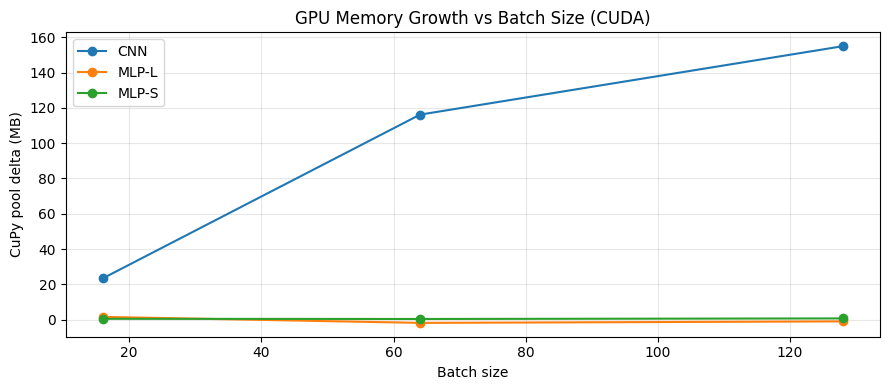

In [14]:
# ── GPU memory benchmark (CUDA only) ─────────────────────────────────────────
if not CUDA_OK:
    print("CUDA not available — skipping memory benchmark.")
else:
    import cupy as cp
    from dnp.core.backend import as_cupy

    def gpu_mem_mb():
        """Free, total GPU memory in MB for device 0."""
        pool  = cp.get_default_memory_pool()
        used  = pool.used_bytes()  / 1024**2
        total = pool.total_bytes() / 1024**2
        return used, total

    mem_rows = []
    dnp.set_device("cuda")
    loss_fn = dnp.CrossEntropyLoss()

    for mname, mcls, batch_shape in MODEL_SPECS:
        for bs in [16, 64, 128]:
            shape = (bs,) + batch_shape[1:]
            model = mcls()
            _move_params(model, "cuda")

            cp.get_default_memory_pool().free_all_blocks()
            synchronize()
            mem_before, _ = gpu_mem_mb()

            session.reset()
            x    = make_tensor(shape, "cuda")
            yidx = dnp.Tensor(as_cupy(np.random.randint(0, 10, bs)))
            out  = model(x)
            loss = loss_fn(out, yidx)
            loss.backward()
            synchronize()

            mem_after, total = gpu_mem_mb()
            delta = mem_after - mem_before

            mem_rows.append(dict(model=mname, batch=bs,
                                 mem_used_mb=round(mem_after, 2),
                                 mem_delta_mb=round(delta, 2)))
            print(f"  {mname:6s}  bs={bs:3d}  pool_used={mem_after:.2f}MB  delta={delta:.2f}MB")

    df_mem = pd.DataFrame(mem_rows)

    # Plot
    fig, ax = plt.subplots(figsize=(9, 4))
    for mname, grp in df_mem.groupby("model"):
        ax.plot(grp["batch"], grp["mem_delta_mb"], marker="o", label=mname)
    ax.set(title="GPU Memory Growth vs Batch Size (CUDA)",
           xlabel="Batch size", ylabel="CuPy pool delta (MB)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()



---
## Section 6 — Before vs After: v3 Performance Improvements

Key optimizations introduced in **v3** and their expected impact:

| ID | Change | What changed | Expected gain |
|----|--------|--------------|---------------|
| **P3** | `avg_pool2d` bwd vectorized | Replaced Python loop over batch/channel with `np.add.at` | 3–10× faster on large tensors |
| **P5** | `DeviceStats` opt-in | `device_stats.enabled=False` by default | ~0 overhead when disabled |
| **P6** | `graph_fn` fast-path | Skips `_to_tensor` loop when all inputs already Tensors | Noticeable on hot inner loops |
| **P7** | Optimizer stable keys | State indexed by enumerate `i` instead of `id(p)` | Correct across GC cycles |

The cell below measures each improvement directly.


In [18]:

# ── Before vs After: v3 improvements ─────────────────────────────────────────
import time, gc
import numpy as _np_raw
from dnp.core.ops import device_stats, Ops

ba_results = {}

# ── P3: avg_pool2d backward — loop vs vectorized ──────────────────────────────
print("P3 — avg_pool2d backward (old Python loop vs v3 vectorized)")

def _avg_pool_bwd_loop(grad, B, C, OH, OW, KH, KW, SH, SW, H, W):
    """Old implementation: 4 nested Python loops over batch/channel/h/w."""
    dx = _np_raw.zeros((B, C, H, W), dtype=grad.dtype)
    scale = 1.0 / (KH * KW)
    for b in range(B):
        for c in range(C):
            for i in range(OH):
                for j in range(OW):
                    dx[b, c, i*SH:i*SH+KH, j*SW:j*SW+KW] += grad[b, c, i, j] * scale
    return dx

def _avg_pool_bwd_vectorized(grad, B, C, OH, OW, KH, KW, SH, SW, H, W):
    """v3: meshgrid kernel offsets, broadcast scatter with np.add.at — zero Python loops."""
    g_scaled = grad / (KH * KW)   # (B, C, OH, OW)

    kh_grid, kw_grid = _np_raw.meshgrid(_np_raw.arange(KH), _np_raw.arange(KW), indexing="ij")
    kh_flat = kh_grid.ravel()     # (K,) K=KH*KW
    kw_flat = kw_grid.ravel()

    h_range = _np_raw.arange(OH, dtype=_np_raw.int64)
    w_range = _np_raw.arange(OW, dtype=_np_raw.int64)
    abs_h = kh_flat[:, None, None] + h_range[None, :, None] * SH  # (K, OH, 1)
    abs_w = kw_flat[:, None, None] + w_range[None, None, :] * SW  # (K, 1, OW)

    b_idx = _np_raw.arange(B)[:, None, None, None, None]   # (B,1,1,1,1)
    c_idx = _np_raw.arange(C)[None, :, None, None, None]   # (1,C,1,1,1)
    h_idx = abs_h[None, None, :, :, :]                     # (1,1,K,OH,1)
    w_idx = abs_w[None, None, :, :, :]                     # (1,1,K,1,OW)
    g_exp = g_scaled[:, :, None, :, :]                     # (B,C,1,OH,OW)

    dx = _np_raw.zeros((B, C, H, W), dtype=grad.dtype)
    _np_raw.add.at(dx, (b_idx, c_idx, h_idx, w_idx), g_exp)
    return dx

REPS_BA = 5
for label, (B, C, H, W) in [("small", (2, 4, 16, 16)), ("medium", (4, 8, 32, 32)), ("large", (8, 16, 64, 64))]:
    KH, KW, SH, SW = 2, 2, 2, 2
    OH, OW = H // SH, W // SW
    grad = _np_raw.random.randn(B, C, OH, OW).astype(_np_raw.float32)

    t0 = time.perf_counter()
    for _ in range(REPS_BA):
        _avg_pool_bwd_loop(grad, B, C, OH, OW, KH, KW, SH, SW, H, W)
    loop_ms = (time.perf_counter() - t0) / REPS_BA * 1000

    t0 = time.perf_counter()
    for _ in range(REPS_BA):
        _avg_pool_bwd_vectorized(grad, B, C, OH, OW, KH, KW, SH, SW, H, W)
    vec_ms = (time.perf_counter() - t0) / REPS_BA * 1000

    speedup = loop_ms / vec_ms if vec_ms > 0 else float("inf")
    ba_results[f"P3_{label}"] = dict(before_ms=round(loop_ms,3), after_ms=round(vec_ms,3), speedup=round(speedup,2))
    print(f"  {label:8s}  before={loop_ms:.2f}ms  after={vec_ms:.2f}ms  speedup={speedup:.2f}x")

# ── P5: DeviceStats overhead — enabled vs disabled ────────────────────────────
print("\nP5 — DeviceStats overhead (enabled vs disabled)")
_x = dnp.Tensor(_np_raw.random.randn(64, 64).astype(_np_raw.float32))
_y = dnp.Tensor(_np_raw.random.randn(64, 64).astype(_np_raw.float32))
REPS_P5 = 500

device_stats.enabled = True
reset_device_stats()
t0 = time.perf_counter()
for _ in range(REPS_P5):
    _ = ops.add(_x, _y)
enabled_ms = (time.perf_counter() - t0) / REPS_P5 * 1000

device_stats.enabled = False
t0 = time.perf_counter()
for _ in range(REPS_P5):
    _ = ops.add(_x, _y)
disabled_ms = (time.perf_counter() - t0) / REPS_P5 * 1000

overhead_pct = 100 * (enabled_ms - disabled_ms) / disabled_ms if disabled_ms > 0 else 0
ba_results["P5"] = dict(enabled_ms=round(enabled_ms,4), disabled_ms=round(disabled_ms,4),
                        overhead_pct=round(overhead_pct,1))
print(f"  enabled={enabled_ms:.4f}ms  disabled={disabled_ms:.4f}ms  overhead={overhead_pct:.1f}%")

# ── P6: graph_fn fast-path — all-Tensor vs numpy array ────────────────────────
print("\nP6 — graph_fn fast-path (all-Tensor input vs numpy array input)")
from dnp.core.session import graph_fn as _graph_fn

# Create a simple op wrapped with graph_fn (mirrors how Ops.__call__ works)
@_graph_fn
def _bench_add(a, b):
    return a + b

_a_t = dnp.Tensor(_np_raw.ones((128, 128), dtype=_np_raw.float32))
_b_t = dnp.Tensor(_np_raw.ones((128, 128), dtype=_np_raw.float32))
_a_np = _np_raw.ones((128, 128), dtype=_np_raw.float32)
_b_np = _np_raw.ones((128, 128), dtype=_np_raw.float32)
REPS_P6 = 200

# Fast path: both already Tensors → skips _to_tensor loop
t0 = time.perf_counter()
for _ in range(REPS_P6):
    _bench_add(_a_t, _b_t)
fast_ms = (time.perf_counter() - t0) / REPS_P6 * 1000

# Slow path: raw numpy arrays → triggers full _to_tensor conversion
t0 = time.perf_counter()
for _ in range(REPS_P6):
    _bench_add(_a_np, _b_np)
slow_ms = (time.perf_counter() - t0) / REPS_P6 * 1000

p6_speedup = slow_ms / fast_ms if fast_ms > 0 else float("inf")
ba_results["P6"] = dict(slow_ms=round(slow_ms,4), fast_ms=round(fast_ms,4), speedup=round(p6_speedup,2))
print(f"  slow(numpy in)={slow_ms:.4f}ms  fast(tensor in)={fast_ms:.4f}ms  speedup={p6_speedup:.2f}x")

# ── P7: Optimizer state key stability ─────────────────────────────────────────
print("\nP7 — Optimizer state key stability across GC cycles")
_model_p7 = dnp.Linear(16, 8)
_opt_p7   = dnp.Adam(_model_p7.parameters(), lr=1e-3)

# Run a step to populate state
_xp7  = dnp.Tensor(_np_raw.random.randn(4, 16).astype(_np_raw.float32))
_outp7 = _model_p7(_xp7)
ops.sum(_outp7).backward()   # use ops.sum — Tensor has no .sum() method
_opt_p7.step()

keys_before = set(_opt_p7.m.keys())

# Simulate GC pressure — reassign the model variable and collect
_model_p7 = None
gc.collect()

keys_after = set(_opt_p7.m.keys())
stable = (keys_before == keys_after)
ba_results["P7"] = dict(keys_before=sorted(keys_before), keys_after=sorted(keys_after), stable=stable)
print(f"  keys before GC: {sorted(keys_before)}")
print(f"  keys after  GC: {sorted(keys_after)}")
print(f"  Stable: {stable}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  Before vs After — v3 Summary")
print("="*65)
for k, v in ba_results.items():
    if k.startswith("P3"):
        print(f"  P3 {k[3:]:8s}  {v['before_ms']:.2f}ms → {v['after_ms']:.2f}ms  ({v['speedup']:.2f}x faster)")
    elif k == "P5":
        print(f"  P5           enabled={v['enabled_ms']:.4f}ms  disabled={v['disabled_ms']:.4f}ms  overhead={v['overhead_pct']:.1f}%")
    elif k == "P6":
        print(f"  P6           numpy-in={v['slow_ms']:.4f}ms  tensor-in={v['fast_ms']:.4f}ms  ({v['speedup']:.2f}x faster)")
    elif k == "P7":
        print(f"  P7           stable keys across GC: {v['stable']}")
print("="*65)


P3 — avg_pool2d backward (old Python loop vs v3 vectorized)
  small     before=1.74ms  after=0.21ms  speedup=8.25x
  medium    before=26.08ms  after=0.80ms  speedup=32.55x
  large     before=423.20ms  after=11.32ms  speedup=37.40x

P5 — DeviceStats overhead (enabled vs disabled)
  enabled=0.0387ms  disabled=0.0365ms  overhead=6.0%

P6 — graph_fn fast-path (all-Tensor input vs numpy array input)
  slow(numpy in)=0.2698ms  fast(tensor in)=0.0408ms  speedup=6.62x

P7 — Optimizer state key stability across GC cycles
  keys before GC: [0, 1]
  keys after  GC: [0, 1]
  Stable: True

  Before vs After — v3 Summary
  P3 small     1.74ms → 0.21ms  (8.25x faster)
  P3 medium    26.08ms → 0.80ms  (32.55x faster)
  P3 large     423.20ms → 11.31ms  (37.40x faster)
  P5           enabled=0.0387ms  disabled=0.0365ms  overhead=6.0%
  P6           numpy-in=0.2698ms  tensor-in=0.0408ms  (6.62x faster)
  P7           stable keys across GC: True


---
## Section 6 — Summary Table

Combined results from all sections, formatted as a single reference table.


In [19]:
# ── Final summary ─────────────────────────────────────────────────────────────
_sep = "─" * 65

print(f"\n{'='*65}")
print("  DifferentialNumpy v3 — Benchmark Summary")
print(f"{'='*65}")

print(f"\n{'OP MICROBENCHMARKS (fwd_graph, ms)':^65}")
print(_sep)
op_pivot = df_ops.pivot_table(index="op", columns="device", values="fwd_graph_ms")
print(op_pivot.to_string())

print(f"\n\n{'MODEL BENCHMARKS (batch={BATCH})':^65}".format(BATCH=BATCH))
print(_sep)
m_pivot = df_models[["model","device","params","fwd_ms","bwd_ms","throughput"]].copy()
print(m_pivot.to_string(index=False))

print(f"\n\n{'TRAINING THROUGHPUT':^65}")
print(_sep)
for dev, res in train_results.items():
    avg_epoch = float(np.mean(res["epoch_times"]))
    tp = N_SAMPLES / (avg_epoch / 1000)
    final_loss = res["history"].history["loss"][-1]
    print(f"  {dev:4s}  avg_epoch={avg_epoch:.1f}ms  "
          f"throughput={tp:.0f} samp/s  final_loss={final_loss:.4f}  "
          f"CPU%={res['cpu_pct']:.1f}  CUDA%={res['cuda_pct']:.1f}")

if CUDA_OK:
    print(f"\n\n{'GPU MEMORY (batch=64)':^65}")
    print(_sep)
    print(df_mem[df_mem["batch"] == 64][["model","mem_delta_mb"]].to_string(index=False))

print(f"\n{'='*65}")
print("  All benchmarks complete.")
print(f"{'='*65}\n")



  DifferentialNumpy v3 — Benchmark Summary

               OP MICROBENCHMARKS (fwd_graph, ms)                
─────────────────────────────────────────────────────────────────
device        cpu    cuda
op                       
add        0.3126  0.0529
exp        0.6740  0.0642
log        2.9896  0.1012
matmul     4.7583  1.4453
mean       0.2585  0.0755
multiply   0.3418  0.0579
relu       1.6126  0.7080
sigmoid   13.6728  1.1923
softmax   10.1858  1.0263
sqrt       0.3392  0.0492
sum        0.2225  0.0458
tanh       3.9813  0.5559


                MODEL BENCHMARKS (batch=64)                 
─────────────────────────────────────────────────────────────────
model device  params  fwd_ms  bwd_ms  throughput
MLP-S    cpu   67210   0.724   2.090     30625.5
MLP-L    cpu  567434   3.218  10.347      6185.4
  CNN    cpu   20042 147.789 486.876       131.5
MLP-S   cuda   67210   0.845   3.245     19724.2
MLP-L   cuda  567434   1.375   4.262     15016.2
  CNN   cuda   20042   6.730  21.082